In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [6]:
[file_name for file_name in os.listdir('data') if ('+' in file_name) or (',' in file_name)]

['san+francisco,ca.csv',
 'new+york,ny.csv',
 'springfield,ma.csv',
 'boston,ma.csv',
 'springfield,il.csv',
 'albany,ny.csv',
 'los+angeles,ca.csv',
 'chicago,il.csv']

In [9]:
df_tmp = pd.read_csv(
    'data/san+francisco,ca.csv',
    usecols=[0, 1, 2],
    names=['date_time', 'maxtemp', 'mintemp'],
    header=0,
    index_col=['date_time']
)
df_tmp

,maxtemp,mintemp
date_time,,
2018-12-11 00:00:00,13,8
2018-12-11 03:00:00,13,8
2018-12-11 06:00:00,13,8
2018-12-11 09:00:00,13,8
2018-12-11 12:00:00,13,8
...,...,...
2019-03-11 09:00:00,12,8
2019-03-11 12:00:00,12,8
2019-03-11 15:00:00,12,8


In [25]:
dataframes = []
for file in [file_name for file_name in os.listdir('data') if ('+' in file_name) or (',' in file_name)]:
    full_name, extension = file.split('.')
    city, state = full_name.split(',')
    city = city.replace('+', ' ')
    df_tmp = pd.read_csv(
        'data/' + file,
        usecols=[0, 1, 2],
        names=['date_time', 'maxtemp', 'mintemp'],
        header=0,
        index_col=['date_time'],
        parse_dates=['date_time']
    )
    df_tmp['city'] = city.title()
    df_tmp['state'] = state.upper()
    dataframes.append(df_tmp)

In [26]:
df = pd.concat(objs=dataframes)
df

,maxtemp,mintemp,city,state
date_time,,,,
2018-12-11 00:00:00,13,8,San Francisco,CA
2018-12-11 03:00:00,13,8,San Francisco,CA
2018-12-11 06:00:00,13,8,San Francisco,CA
2018-12-11 09:00:00,13,8,San Francisco,CA
2018-12-11 12:00:00,13,8,San Francisco,CA
...,...,...,...,...
2019-03-11 09:00:00,3,-2,Chicago,IL
2019-03-11 12:00:00,3,-2,Chicago,IL
2019-03-11 15:00:00,3,-2,Chicago,IL


In [27]:
df = df.loc[df['city'].isin(['Chicago', 'Los Angeles', 'Boston']), :]

In [28]:
df

,maxtemp,mintemp,city,state
date_time,,,,
2018-12-11 00:00:00,1,-4,Boston,MA
2018-12-11 03:00:00,1,-4,Boston,MA
2018-12-11 06:00:00,1,-4,Boston,MA
2018-12-11 09:00:00,1,-4,Boston,MA
2018-12-11 12:00:00,1,-4,Boston,MA
...,...,...,...,...
2019-03-11 09:00:00,3,-2,Chicago,IL
2019-03-11 12:00:00,3,-2,Chicago,IL
2019-03-11 15:00:00,3,-2,Chicago,IL


<Axes: >

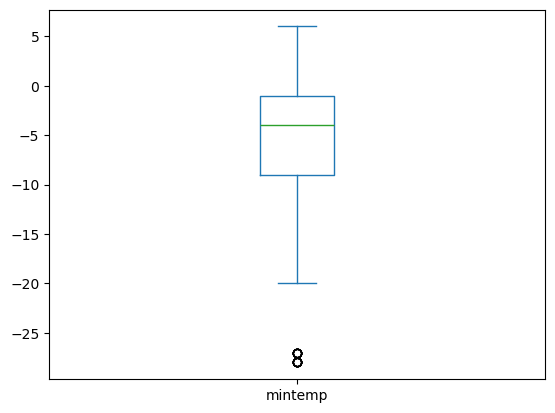

In [29]:
df.loc[df['city'] == 'Chicago', 'mintemp'].plot.box()

In [30]:
ch = df.loc[df['city'] == 'Chicago']

In [31]:
ch

,maxtemp,mintemp,city,state
date_time,,,,
2018-12-11 00:00:00,1,-2,Chicago,IL
2018-12-11 03:00:00,1,-2,Chicago,IL
2018-12-11 06:00:00,1,-2,Chicago,IL
2018-12-11 09:00:00,1,-2,Chicago,IL
2018-12-11 12:00:00,1,-2,Chicago,IL
...,...,...,...,...
2019-03-11 09:00:00,3,-2,Chicago,IL
2019-03-11 12:00:00,3,-2,Chicago,IL
2019-03-11 15:00:00,3,-2,Chicago,IL


In [35]:
ch.loc[ch['mintemp'] < ch['mintemp'].quantile(0.25) - 1.5 * (ch['mintemp'].quantile(0.75) - ch['mintemp'].quantile(0.25))]['mintemp'].unique()

array([-28, -27])

<Axes: >

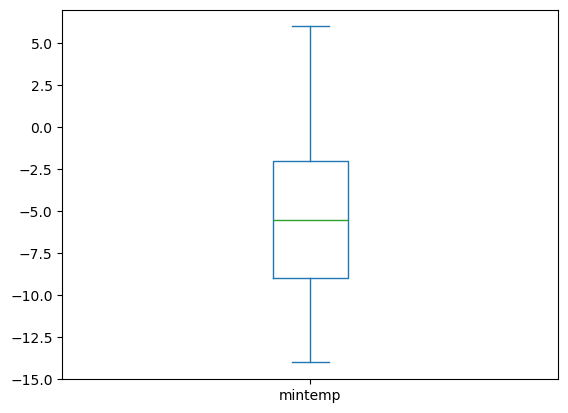

In [38]:
ch.loc['2019-02', 'mintemp'].plot.box()

<Axes: >

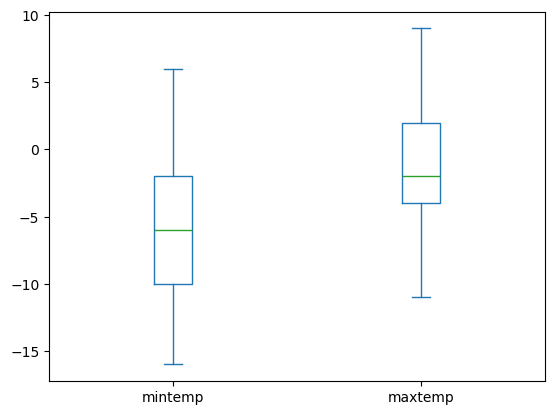

In [42]:
ch.loc['2019-02':'2019-03', ['mintemp', 'maxtemp']].plot.box()

In [46]:
df.groupby(by=['city'])[['mintemp', 'maxtemp']].apply(pd.DataFrame.describe)

mintemp     maxtemp
city                                     
Boston      count  728.000000  728.000000
            mean    -3.142857    2.868132
            std      4.957195    4.945277
            min    -14.000000  -12.000000
            25%     -6.000000    0.000000
            50%     -3.000000    2.000000
            75%      0.000000    6.000000
            max      9.000000   17.000000
Chicago     count  728.000000  728.000000
            mean    -5.076923   -0.736264
            std      6.255857    6.128985
            min    -28.000000  -25.000000
            25%     -9.000000   -3.000000
            50%     -4.000000    0.000000
            75%     -1.000000    3.000000
            max      6.000000    9.000000
Los Angeles count  728.000000  728.000000
            mean    10.637363   17.054945
            std      2.705200    2.708640
            min      4.000000   12.000000
            25%      9.000000   15.000000
            50%     11.000000   16.000000
            75%     12.000000   19.000000
            max     17.000000   23.000000

maxtemp       Axes(0.125,0.11;0.352273x0.77)
mintemp    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

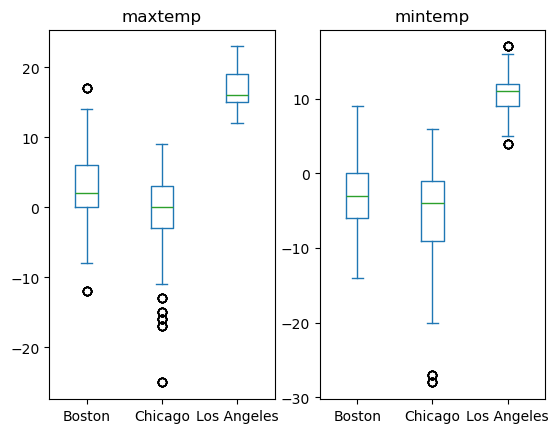

In [44]:
df[['city', 'mintemp', 'maxtemp']].plot.box(by='city')

In [47]:
# 44.1

In [48]:
df

,maxtemp,mintemp,city,state
date_time,,,,
2018-12-11 00:00:00,1,-4,Boston,MA
2018-12-11 03:00:00,1,-4,Boston,MA
2018-12-11 06:00:00,1,-4,Boston,MA
2018-12-11 09:00:00,1,-4,Boston,MA
2018-12-11 12:00:00,1,-4,Boston,MA
...,...,...,...,...
2019-03-11 09:00:00,3,-2,Chicago,IL
2019-03-11 12:00:00,3,-2,Chicago,IL
2019-03-11 15:00:00,3,-2,Chicago,IL


In [49]:
# 44.2

In [51]:
df.groupby(by=['city'])[['mintemp', 'maxtemp']].agg(['mean', 'median'])

mintemp           maxtemp       
                  mean median       mean median
city                                           
Boston       -3.142857   -3.0   2.868132    2.0
Chicago      -5.076923   -4.0  -0.736264    0.0
Los Angeles  10.637363   11.0  17.054945   16.0

In [52]:
# 44.3

city
Boston         Axes(0.125,0.11;0.775x0.77)
Chicago        Axes(0.125,0.11;0.775x0.77)
Los Angeles    Axes(0.125,0.11;0.775x0.77)
Name: mintemp, dtype: object

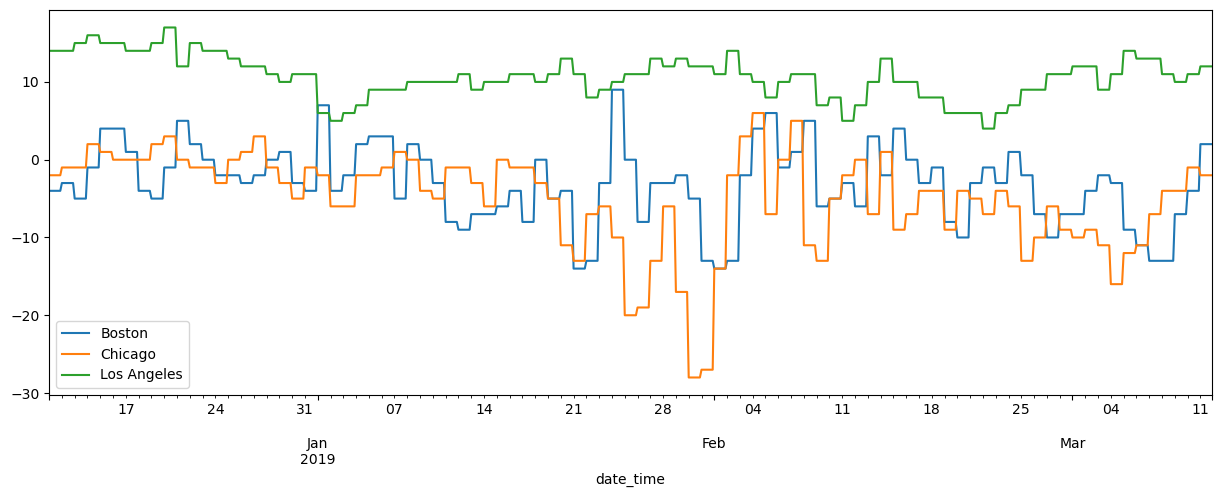

In [60]:
df.groupby(by=['city'])['mintemp'].plot.line(figsize=(15, 5), legend=True)